# Customer Churn Prediction — Experiment Notebook

**Goal:** predict which telecom customers are likely to cancel their subscription (*churn*), so the business can target them with retention offers before they leave.

**What this notebook documents**

1. Loading the dataset
2. Basic data exploration
3. Experiment setup (split, preprocessing, metric)
4. Model training — five candidate models compared with 5-fold cross-validation
5. Feature-selection experiment
6. Final evaluation on the held-out test set
7. Conclusions

All reusable code (cleaning, preprocessing, model definitions, metrics) lives in `models/model.py`, so the notebook and the final model use exactly the same steps.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate

# Make models/model.py importable when the notebook runs from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "models"))
import model as m

REPORTS = PROJECT_ROOT / "reports"
REPORTS.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 30)
print("Random seed used everywhere:", m.RANDOM_STATE)

Random seed used everywhere: 42


## 1. Load the dataset

The data is the **IBM Telco Customer Churn** dataset (`data/telco_customer_churn.csv`): one row per customer, 21 columns covering demographics, subscribed services, account details, and whether the customer churned.

First we look at the raw file *before* any cleaning, to see what problems need handling.

In [2]:
raw = pd.read_csv(m.DATA_PATH)
print("Shape:", raw.shape)
raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Observation:** `TotalCharges` is stored as `object` (text), not a number. Let's see why.

In [4]:
bad = pd.to_numeric(raw["TotalCharges"], errors="coerce").isna()
print("Rows where TotalCharges is not a number:", bad.sum())
raw.loc[bad, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Rows where TotalCharges is not a number: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


All 11 problem rows have `tenure = 0` — brand-new customers who have not been billed yet. Their total charge is genuinely **0**, so `load_data()` fills them with 0 instead of dropping them or imputing an average. It also converts `SeniorCitizen` (0/1) to Yes/No so it is treated as a category, and encodes the target `Churn` as 1 = Yes, 0 = No.

In [5]:
df = m.load_data()
print("Missing values after cleaning:", df.isna().sum().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())
df[m.NUMERIC_FEATURES].describe().round(2)

Missing values after cleaning: 0
Duplicate customer IDs: 0


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


## 2. Basic data exploration

### 2.1 How imbalanced is the target?

Churn rate: 26.5%  (1869 of 7043 customers)


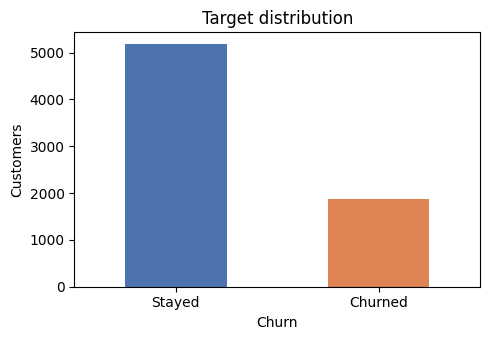

In [6]:
rate = df["Churn"].mean()
print(f"Churn rate: {rate:.1%}  ({df['Churn'].sum()} of {len(df)} customers)")

ax = df["Churn"].map({0: "Stayed", 1: "Churned"}).value_counts().plot(
    kind="bar", color=["#4C72B0", "#DD8452"], rot=0, figsize=(5, 3.5))
ax.set_title("Target distribution"); ax.set_ylabel("Customers")
plt.tight_layout(); plt.savefig(REPORTS / "churn_distribution.png", dpi=120); plt.show()

Only about **26.5%** of customers churn. This matters for evaluation: a "model" that always predicts *No churn* would already be **73.5% accurate** while catching zero churners. Accuracy alone is therefore a misleading metric here (see Decision 2 in `decision_log.txt`).

### 2.2 Which customer attributes relate to churn?

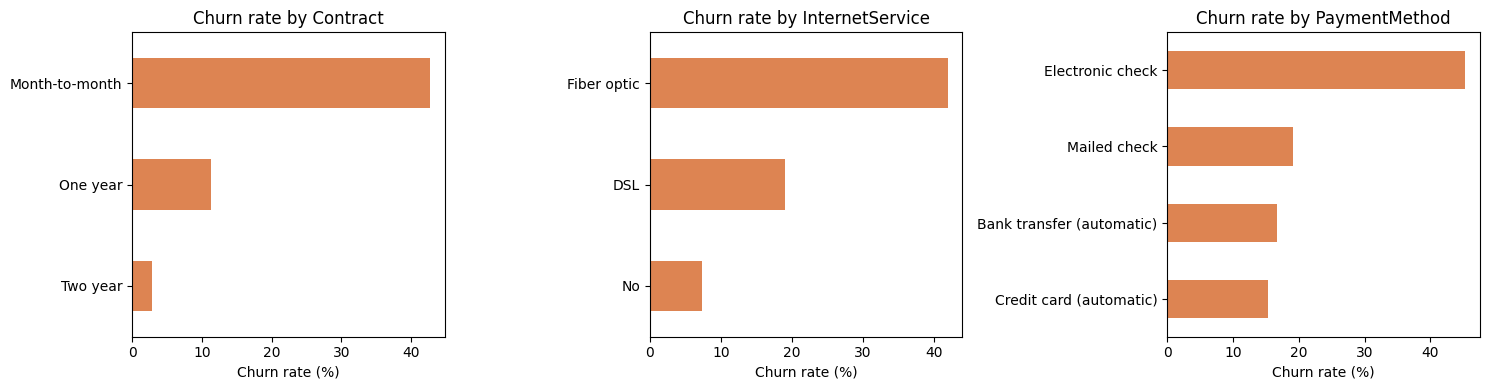

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    (df.groupby(col)["Churn"].mean().sort_values() * 100).plot(kind="barh", ax=ax, color="#DD8452")
    ax.set_title(f"Churn rate by {col}"); ax.set_xlabel("Churn rate (%)"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(REPORTS / "churn_by_category.png", dpi=120); plt.show()

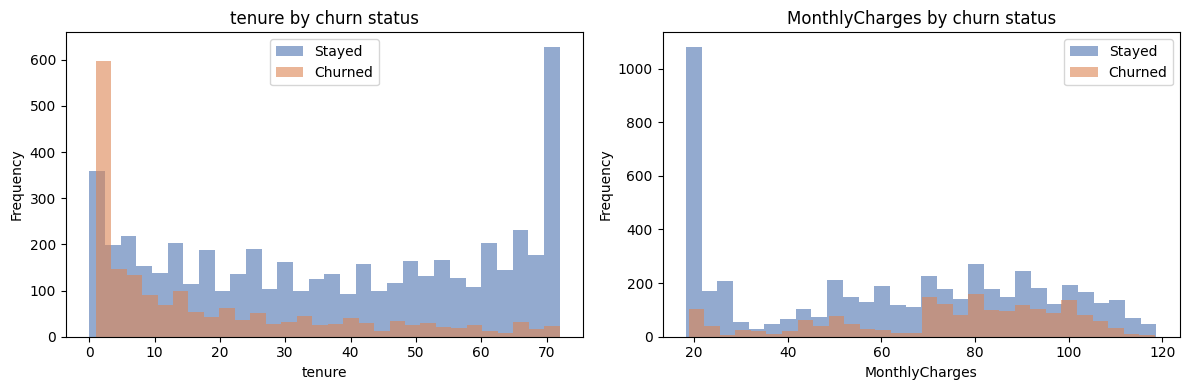

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    for label, colour in [(0, "#4C72B0"), (1, "#DD8452")]:
        df.loc[df["Churn"] == label, col].plot(kind="hist", bins=30, alpha=0.6, ax=ax, color=colour,
                                               label="Churned" if label else "Stayed")
    ax.set_title(f"{col} by churn status"); ax.set_xlabel(col); ax.legend()
plt.tight_layout(); plt.savefig(REPORTS / "numeric_by_churn.png", dpi=120); plt.show()

In [9]:
# Churn rate for every categorical feature — used later to judge which features carry signal
spread = {c: df.groupby(c)["Churn"].mean().max() - df.groupby(c)["Churn"].mean().min()
          for c in m.CATEGORICAL_FEATURES}
pd.Series(spread, name="churn-rate spread between categories").sort_values(ascending=False).round(3).to_frame()

,churn-rate spread between categories
Contract,0.399
InternetService,0.345
OnlineSecurity,0.344
TechSupport,0.342
OnlineBackup,0.325
DeviceProtection,0.317
PaymentMethod,0.300
StreamingMovies,0.263
StreamingTV,0.261
SeniorCitizen,0.181


**Exploration findings**

- **Contract type** is the strongest signal: month-to-month customers churn far more (~43%) than one-year (~11%) or two-year (~3%) customers.
- **Tenure:** churners are concentrated in the first months; long-standing customers rarely leave.
- **Fibre-optic internet** and **electronic-check payment** are associated with higher churn.
- Churners tend to have **higher monthly charges**.
- **`gender`** and **`PhoneService`** show almost no difference in churn rate between categories — candidates for removal, tested in Section 5.
- `customerID` is a unique identifier with no predictive meaning, so it is never used as a feature.

## 3. Experiment setup

| Choice | Setting | Why |
|---|---|---|
| Split | 80% train / 20% test, **stratified**, seed 42 | Keeps the 26.5% churn rate in both sets; seed makes it reproducible |
| Model selection | **5-fold stratified cross-validation on the training set only** | The test set is touched once, at the very end, so the final score is an honest estimate |
| Preprocessing | `StandardScaler` for numeric, `OneHotEncoder` for categorical, inside a `Pipeline` | Fitting inside the pipeline prevents information leaking from validation folds |
| Primary metric | **F1-score** for the churn class, with recall and ROC-AUC as supporting metrics | Accuracy is misleading on imbalanced data (Section 2.1) |

In [10]:
X_train, X_test, y_train, y_test = m.split_data(df)
print(f"Train: {X_train.shape}, churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.1%}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=m.RANDOM_STATE)
SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc"]

def cv_scores(pipeline):
    res = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=SCORING)
    return {s: res[f"test_{s}"].mean() for s in SCORING} | {"f1_std": res["test_f1"].std()}

Train: (5634, 19), churn rate 26.5%
Test:  (1409, 19), churn rate 26.5%


## 4. Experiment 1 — Model comparison

**What was tested:** five models, all using the same preprocessing and all features.

| Model | Why it is included |
|---|---|
| Baseline (majority class) | Lower bound — any real model must beat it |
| Logistic Regression | Simple, fast, interpretable linear model |
| Logistic Regression (balanced) | Same model, but `class_weight="balanced"` gives churners more weight to counter the imbalance |
| Decision Tree (max_depth=5) | Non-linear and easy to explain; depth limited to avoid overfitting |
| Random Forest (300 trees) | Stronger non-linear ensemble, usually a good benchmark |

In [11]:
results = pd.DataFrame({name: cv_scores(m.build_pipeline(model))
                        for name, model in m.get_candidate_models().items()}).T
results = results.sort_values("f1", ascending=False)
results.to_csv(REPORTS / "cv_model_comparison.csv")
results.round(3)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_clas

,accuracy,precision,recall,f1,roc_auc,f1_std
Logistic Regression (balanced),0.748,0.517,0.801,0.628,0.846,0.023
Logistic Regression,0.802,0.652,0.544,0.592,0.846,0.030
Random Forest,0.804,0.677,0.498,0.574,0.845,0.021
Decision Tree,0.791,0.634,0.513,0.565,0.829,0.031
Baseline (majority class),0.735,0.000,0.000,0.000,0.500,0.000


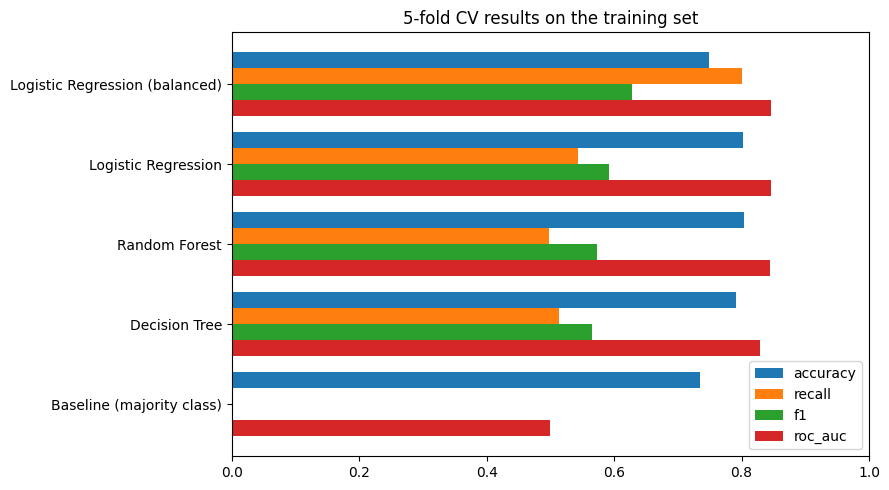

In [12]:
ax = results[["accuracy", "recall", "f1", "roc_auc"]].plot(kind="barh", figsize=(9, 5), width=0.8)
ax.set_title("5-fold CV results on the training set"); ax.set_xlim(0, 1); ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(REPORTS / "cv_model_comparison.png", dpi=120); plt.show()

**Results of Experiment 1**

- The **baseline** reaches ~73.5% accuracy but **0 recall** — confirming that accuracy alone would be misleading.
- Plain Logistic Regression, Decision Tree and Random Forest all have **~80% accuracy** but miss roughly half of the churners (recall ≈ 0.50–0.54).
- **Logistic Regression (balanced)** trades some accuracy (~75%) for much higher **recall (~0.80)** and achieves the **best F1 (~0.63)**. Its ROC-AUC (~0.846) ties for the best, meaning its ranking of customers by risk is as good as the Random Forest's.
- The more complex Random Forest did **not** beat the linear model on any churn-focused metric, so the extra complexity is not justified.

**Decision:** Logistic Regression with balanced class weights is chosen as the final model (Decision 1 in `decision_log.txt`).

## 5. Experiment 2 — Feature selection

**What was tested:** does removing the two features with almost no churn signal in Section 2 (`gender`, `PhoneService`) change performance for the chosen model?

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def lr_balanced_with(categorical):
    pre = ColumnTransformer([("num", StandardScaler(), m.NUMERIC_FEATURES),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)])
    return Pipeline([("preprocess", pre),
                     ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                  random_state=m.RANDOM_STATE))])

reduced = [c for c in m.CATEGORICAL_FEATURES if c not in ("gender", "PhoneService")]
feature_results = pd.DataFrame({
    f"All features ({len(m.NUMERIC_FEATURES) + len(m.CATEGORICAL_FEATURES)})": cv_scores(lr_balanced_with(m.CATEGORICAL_FEATURES)),
    f"Without gender & PhoneService ({len(m.NUMERIC_FEATURES) + len(reduced)})": cv_scores(lr_balanced_with(reduced)),
}).T
feature_results.to_csv(REPORTS / "cv_feature_selection.csv")
feature_results.round(3)

,accuracy,precision,recall,f1,roc_auc,f1_std
All features (19),0.748,0.517,0.801,0.628,0.846,0.023
Without gender & PhoneService (17),0.749,0.518,0.802,0.629,0.846,0.023


**Results of Experiment 2:** removing `gender` and `PhoneService` changes F1 and ROC-AUC by well under the cross-validation standard deviation (`f1_std`) — i.e. the difference is noise. Neither version is meaningfully better.

**Decision:** keep all 19 customer features (only `customerID` is excluded). Removing features gives no measurable gain, and keeping the full set keeps the pipeline simpler and avoids discarding information that could matter on future data (Decision 3 in `decision_log.txt`).

## 6. Final evaluation on the held-out test set

The chosen model is now trained on the full training set and evaluated **once** on the 20% test set it has never seen.

In [14]:
final_model = m.build_final_model().fit(X_train, y_train)
test_metrics = pd.Series(m.evaluate(final_model, X_test, y_test), name="Test set").round(3)
test_metrics.to_frame()

,Test set
accuracy,0.738
precision,0.504
recall,0.783
f1,0.614
roc_auc,0.842


              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



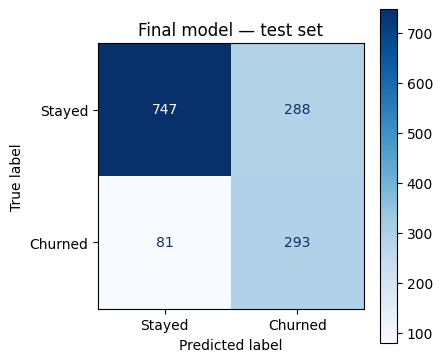

In [15]:
print(classification_report(y_test, final_model.predict(X_test), target_names=["Stayed", "Churned"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, display_labels=["Stayed", "Churned"],
                                      cmap="Blues", ax=ax)
ax.set_title("Final model — test set")
plt.tight_layout(); plt.savefig(REPORTS / "confusion_matrix.png", dpi=120); plt.show()

### 6.1 What drives the predictions?

Because the model is linear, its coefficients show which (scaled / one-hot) features push a customer towards or away from churn.

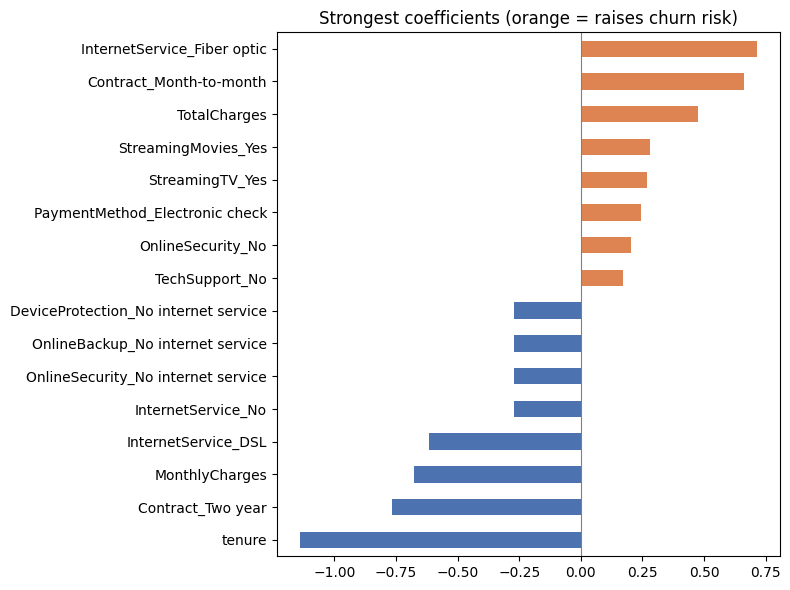

In [16]:
names = final_model.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(final_model.named_steps["model"].coef_[0], index=names)
top = pd.concat([coefs.nsmallest(8), coefs.nlargest(8)]).sort_values()
top.index = top.index.str.replace("num__", "").str.replace("cat__", "")

ax = top.plot(kind="barh", figsize=(8, 6), color=["#4C72B0" if v < 0 else "#DD8452" for v in top])
ax.set_title("Strongest coefficients (orange = raises churn risk)"); ax.axvline(0, color="grey", lw=0.8)
plt.tight_layout(); plt.savefig(REPORTS / "top_coefficients.png", dpi=120); plt.show()

The coefficients agree with the exploration: short tenure, month-to-month contracts and fibre-optic internet raise churn risk, while long contracts and longer tenure lower it. This consistency is a useful sanity check that the model learned sensible patterns.

*Caveat:* `MonthlyCharges` gets a negative coefficient even though churners pay more on average. This is because it overlaps heavily with `TotalCharges`, `tenure` and the service columns (multicollinearity), so individual coefficients should be read as rough indicators, not exact effects.

## 7. Conclusions

**What was tested**
- Five models (baseline, two Logistic Regression variants, Decision Tree, Random Forest) with 5-fold stratified cross-validation.
- Whether removing the two weakest features improves the chosen model.

**What results were achieved**
- Final model: **Logistic Regression with balanced class weights**, trained on all 19 features.
- On the unseen test set it catches **~78% of churners** (recall 0.783) with **F1 ≈ 0.61** and **ROC-AUC ≈ 0.84**. Test scores are close to the cross-validation scores, so the model generalises and is not overfitting.

**How the model performed — and the trade-off**
- Compared with unweighted models (~80% accuracy, recall ~0.55), the chosen model has lower accuracy (~74%) and precision (~0.50): about half of the customers it flags would not actually have left.
- For retention this is usually acceptable: a discount offered to a loyal customer costs far less than losing a customer who was about to leave. If offers were expensive, the decision threshold could be raised to favour precision instead.

**Possible next steps**
- Tune the decision threshold against the real cost of a retention offer vs. a lost customer.
- Try gradient boosting (e.g. `HistGradientBoostingClassifier`) with hyperparameter search.
- Engineer features such as number of subscribed services or average charge per month of tenure.